# Laboratorio 1 Parte A

## Cifrado César 

In [19]:
class CaesarCipher:
    def __init__(self):
        self.alphabet = "abcdefghijklmnñopqrstuvwxyz"
        self.alphabet_size = len(self.alphabet)

    def encrypt(self, text, shift):
        encrypted_text = ""

        for char in text:
            if char.lower() in self.alphabet:  
                is_upper = char.isupper()
                idx = self.alphabet.index(char.lower())
                new_idx = (idx + shift) % self.alphabet_size
                new_char = self.alphabet[new_idx].upper() if is_upper else self.alphabet[new_idx]
                encrypted_text += new_char
            else:
                encrypted_text += char  # Mantener los caracteres no alfabéticos sin cambios

        return encrypted_text

    def decrypt(self, text, shift):
        """Descifra un texto usando el Cifrado César."""
        return self.encrypt(text, -shift)  



cipher = CaesarCipher()

text = "Hola Mundo, esto es un cifrado César con Ñ!"
shift = 4  

encrypted_text = cipher.encrypt(text, shift)
decrypted_text = cipher.decrypt(encrypted_text, shift)

print(f"Texto original  : {text}")
print(f"Texto cifrado   : {encrypted_text}")
print(f"Texto descifrado: {decrypted_text}")

Texto original  : Hola Mundo, esto es un cifrado César con Ñ!
Texto cifrado   : Lsoe Pyqhs, iwxs iw yq gmjvehs Géwev gsq R!
Texto descifrado: Hola Mundo, esto es un cifrado César con Ñ!


### Referencias 

1. GPT
2. https://www.geeksforgeeks.org/caesar-cipher-in-cryptography/
3. https://medium.com/@Operaho/make-a-caesars-cipher-with-python-8958ffa1e90d

## Cifrado Afín 


In [20]:
import math

class AffineCipher:
    def __init__(self):
        self.alphabet = "abcdefghijklmnñopqrstuvwxyz"
        self.alphabet_size = len(self.alphabet)

    def mod_inverse(self, a, m):
        """Calcula el inverso modular de 'a' mod 'm' usando el algoritmo extendido de Euclides."""
        for x in range(1, m):
            if (a * x) % m == 1:
                return x
        return None  # No existe inverso si no son coprimos

    def encrypt(self, text, alpha, beta):
        """Cifra un texto usando el Cifrado Afín: E(x) = (α * x + β) mod m."""
        if math.gcd(alpha, self.alphabet_size) != 1:
            raise ValueError("Alpha (α) debe ser coprimo con el tamaño del alfabeto.")

        encrypted_text = ""

        for char in text:
            if char.lower() in self.alphabet:  
                is_upper = char.isupper()
                idx = self.alphabet.index(char.lower())
                new_idx = (alpha * idx + beta) % self.alphabet_size
                new_char = self.alphabet[new_idx].upper() if is_upper else self.alphabet[new_idx]
                encrypted_text += new_char
            else:
                encrypted_text += char  # Mantener caracteres no alfabéticos sin cambios

        return encrypted_text

    def decrypt(self, text, alpha, beta):
        """Descifra un texto usando el Cifrado Afín: D(y) = α⁻¹ * (y - β) mod m."""
        alpha_inv = self.mod_inverse(alpha, self.alphabet_size)
        if alpha_inv is None:
            raise ValueError("Alpha (α) no tiene inverso modular, elige otro valor.")

        decrypted_text = ""

        for char in text:
            if char.lower() in self.alphabet:
                is_upper = char.isupper()
                idx = self.alphabet.index(char.lower())
                new_idx = (alpha_inv * (idx - beta)) % self.alphabet_size
                new_char = self.alphabet[new_idx].upper() if is_upper else self.alphabet[new_idx]
                decrypted_text += new_char
            else:
                decrypted_text += char  # Mantener caracteres no alfabéticos sin cambios

        return decrypted_text


cipher = AffineCipher()

plaintext = "Hola Mundo, esto es un cifrado afín con Ñ!"
alpha = 5  
beta = 8   

encrypted_text = cipher.encrypt(plaintext, alpha, beta)
decrypted_text = cipher.decrypt(encrypted_text, alpha, beta)

print(f"Texto original  : {plaintext}")
print(f"Texto cifrado   : {encrypted_text}")
print(f"Texto descifrado: {decrypted_text}")

Texto original  : Hola Mundo, esto es un cifrado afín con Ñ!
Texto cifrado   : Pcji Ñfswc, bvac bv fs rugqiwc igís rcs X!
Texto descifrado: Hola Mundo, esto es un cifrado afín con Ñ!


### Referencias

1. https://github.com/LeoMartinezTAMUK/Affine_Cipher_Encryption-Decryption/blob/main/src/main.py
2. https://www.geeksforgeeks.org/implementation-affine-cipher/
3. https://medium.com/@momtajhossain2001/implementation-of-affine-cipher-in-python-a8ca5951abad
4. https://github.com/MomtajHossainMow/Cryptography_And_Information_Security/blob/main/Final%20Exam/Affine_Cipher.ipynb
5. GPT

## Cifrado Vigenére

In [21]:
import math
from colorama import init, Fore


init(autoreset=True)

class VigenereCipher:
    def __init__(self):
        # Definir el alfabeto español incluyendo la "ñ"
        self.alphabet = "abcdefghijklmnñopqrstuvwxyz"
        self.alphabet_size = len(self.alphabet)

    def generate_key(self, text, key):
        """Genera una clave repetida hasta igualar la longitud del texto."""
        key = list(key)
        if len(text) == len(key):
            return "".join(key)
        else:
            return "".join(key[i % len(key)] for i in range(len(text)))

    def encrypt(self, text, key):
        """Cifra un texto usando el Cifrado Vigenère."""
        key = self.generate_key(text, key)
        encrypted_text = ""

        for i in range(len(text)):
            char = text[i]
            if char.lower() in self.alphabet:
                is_upper = char.isupper()
                text_idx = self.alphabet.index(char.lower())
                key_idx = self.alphabet.index(key[i].lower())
                new_idx = (text_idx + key_idx) % self.alphabet_size
                new_char = self.alphabet[new_idx].upper() if is_upper else self.alphabet[new_idx]
                encrypted_text += new_char
            else:
                encrypted_text += char  # Mantener caracteres especiales sin cambios

        return encrypted_text

    def decrypt(self, text, key):
        """Descifra un texto usando el Cifrado Vigenère."""
        key = self.generate_key(text, key)
        decrypted_text = ""

        for i in range(len(text)):
            char = text[i]
            if char.lower() in self.alphabet:
                is_upper = char.isupper()
                text_idx = self.alphabet.index(char.lower())
                key_idx = self.alphabet.index(key[i].lower())
                new_idx = (text_idx - key_idx) % self.alphabet_size
                new_char = self.alphabet[new_idx].upper() if is_upper else self.alphabet[new_idx]
                decrypted_text += new_char
            else:
                decrypted_text += char  # Mantener caracteres especiales sin cambios

        return decrypted_text


cipher = VigenereCipher()

plaintext = "Hola Mundo, esto es un cifrado Vigenère con Ñ!"
key = "llave"  # Clave para cifrar

encrypted_text = cipher.encrypt(plaintext, key)

decrypted_text = cipher.decrypt(encrypted_text, key)

print(Fore.CYAN + f"Texto original  : {plaintext}")
print(Fore.GREEN + f"Texto cifrado   : {encrypted_text}")
print(Fore.YELLOW + f"Texto descifrado: {decrypted_text}")

Texto original  : Hola Mundo, esto es un cifrado Vigenère con Ñ!
Texto cifrado   : Rzlv Wfnys, eñxz eñ fx xmpcays Gibixèrz nzn R!
Texto descifrado: Hola Mundo, esto es un cifrado Vigenère con Ñ!


### Referencias

1. https://www.geeksforgeeks.org/vigenere-cipher/
2. https://thepythoncode.com/article/implementing-the-vigenere-cipher-in-python
3. https://medium.com/@goldengrisha/a-simple-guide-to-implementing-a-vigenère-cipher-in-python-abc5918a392e
4. GPT

## Inciso 2

In [27]:
from prettytable import PrettyTable
from collections import Counter
from colorama import init, Fore

# Inicializar colorama para colores en la consola
init(autoreset=True)

class FrequencyAnalyzer:
    def __init__(self):
        # Definir el alfabeto español incluyendo la "ñ"
        self.alphabet = "abcdefghijklmnñopqrstuvwxyz"

    def analyze_frequency(self, text):
        """Analiza la frecuencia de caracteres en un texto y calcula su probabilidad."""
        text = text.lower()  # Convertir el texto a minúsculas
        total_chars = sum(1 for char in text if char in self.alphabet)  # Contar solo letras del alfabeto

        # Contar la frecuencia de cada carácter en el texto
        char_counts = Counter(char for char in text if char in self.alphabet)

        # Calcular la probabilidad dividiendo la frecuencia entre el total de caracteres
        probabilities = {char: (count / total_chars) if total_chars > 0 else 0 for char, count in char_counts.items()}

        return char_counts, probabilities

    def display_results(self, text):
        """Muestra los resultados en una tabla ordenada por frecuencia de mayor a menor."""
        frequencies, probabilities = self.analyze_frequency(text)

        # Crear la tabla usando PrettyTable
        table = PrettyTable()
        table.field_names = ["Letra", "Frecuencia", "Probabilidad (%)"]
        table.align = "c"

        # Ordenar caracteres por frecuencia de mayor a menor y mostrar solo los que aparecen en el texto
        sorted_chars = sorted(frequencies.items(), key=lambda x: x[1], reverse=True)

        for char, freq in sorted_chars:
            prob = probabilities[char] * 100  # Convertir a porcentaje
            table.add_row([char.upper(), freq, f"{prob:.2f}"])

        print(Fore.CYAN + "\n📊 Análisis de Frecuencia de Caracteres 📊")
        print(table)


# ✅ Ejemplo de uso con texto hardcodeado:
text = "Hola Mundo, esto es un análisis de frecuencia para cifrados clásicos como Vigenère y César en español."

analyzer = FrequencyAnalyzer()
analyzer.display_results(text)


📊 Análisis de Frecuencia de Caracteres 📊
+-------+------------+------------------+
| Letra | Frecuencia | Probabilidad (%) |
+-------+------------+------------------+
|   E   |     9      |      11.25       |
|   S   |     9      |      11.25       |
|   O   |     8      |      10.00       |
|   A   |     8      |      10.00       |
|   C   |     7      |       8.75       |
|   N   |     6      |       7.50       |
|   I   |     6      |       7.50       |
|   R   |     5      |       6.25       |
|   L   |     4      |       5.00       |
|   U   |     3      |       3.75       |
|   D   |     3      |       3.75       |
|   M   |     2      |       2.50       |
|   F   |     2      |       2.50       |
|   P   |     2      |       2.50       |
|   H   |     1      |       1.25       |
|   T   |     1      |       1.25       |
|   V   |     1      |       1.25       |
|   G   |     1      |       1.25       |
|   Y   |     1      |       1.25       |
|   Ñ   |     1      |       1.25 

### Fácil

In [31]:
# 📌 Nivel de Dificultad: Fácil
textos_facil = {
    "Fácil": {
        "texto": "Hola Mundo",
        "shift": 4,
        "key": "llave",
        "alpha": 5,
        "beta": 8
    }
}

# 📌 Instanciar los cifrados
caesar_cipher = CaesarCipher()
vigenere_cipher = VigenereCipher()
affine_cipher = AffineCipher()

# 📌 Iterar sobre los textos del nivel Fácil
for nivel, valores in textos_facil.items():
    print(Fore.YELLOW + f"\n🔹 Nivel de Dificultad: {nivel}")

    # 🔐 Cifrado César
    caesar_encrypted = caesar_cipher.encrypt(valores["texto"], valores["shift"])
    caesar_decrypted = caesar_cipher.decrypt(caesar_encrypted, valores["shift"])
    print(Fore.CYAN + f"📌 César - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {caesar_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {caesar_decrypted}")

    # 🔐 Cifrado Vigenère
    vigenere_encrypted = vigenere_cipher.encrypt(valores["texto"], valores["key"])
    vigenere_decrypted = vigenere_cipher.decrypt(vigenere_encrypted, valores["key"])
    print(Fore.CYAN + f"\n📌 Vigenère - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {vigenere_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {vigenere_decrypted}")

    # 🔐 Cifrado Afín
    affine_encrypted = affine_cipher.encrypt(valores["texto"], valores["alpha"], valores["beta"])
    affine_decrypted = affine_cipher.decrypt(affine_encrypted, valores["alpha"], valores["beta"])
    print(Fore.CYAN + f"\n📌 Afín - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {affine_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {affine_decrypted}")

    # 📊 Generar tabla de frecuencia
    analyzer = FrequencyAnalyzer()
    analyzer.display_results(caesar_encrypted)
    analyzer.display_results(vigenere_encrypted)
    analyzer.display_results(affine_encrypted)


🔹 Nivel de Dificultad: Fácil
📌 César - Fácil
   Texto cifrado   : Lsoe Pyqhs
   Texto descifrado: Hola Mundo

📌 Vigenère - Fácil
   Texto cifrado   : Rzlv Wfnys
   Texto descifrado: Hola Mundo

📌 Afín - Fácil
   Texto cifrado   : Pcji Ñfswc
   Texto descifrado: Hola Mundo

📊 Análisis de Frecuencia de Caracteres 📊
+-------+------------+------------------+
| Letra | Frecuencia | Probabilidad (%) |
+-------+------------+------------------+
|   S   |     2      |      22.22       |
|   L   |     1      |      11.11       |
|   O   |     1      |      11.11       |
|   E   |     1      |      11.11       |
|   P   |     1      |      11.11       |
|   Y   |     1      |      11.11       |
|   Q   |     1      |      11.11       |
|   H   |     1      |      11.11       |
+-------+------------+------------------+

📊 Análisis de Frecuencia de Caracteres 📊
+-------+------------+------------------+
| Letra | Frecuencia | Probabilidad (%) |
+-------+------------+------------------+
|   R   |   

### Intermedio

In [32]:
# 📌 Nivel de Dificultad: Intermedio
textos_intermedio = {
    "Intermedio": {
        "texto": "Esto es un cifrado intermedio con más palabras y caracteres especiales!",
        "shift": 10,
        "key": "seguridad",
        "alpha": 7,
        "beta": 3
    }
}

# 📌 Iterar sobre los textos del nivel Intermedio
for nivel, valores in textos_intermedio.items():
    print(Fore.YELLOW + f"\n🔹 Nivel de Dificultad: {nivel}")

    # 🔐 Cifrado César
    caesar_encrypted = caesar_cipher.encrypt(valores["texto"], valores["shift"])
    caesar_decrypted = caesar_cipher.decrypt(caesar_encrypted, valores["shift"])
    print(Fore.CYAN + f"📌 César - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {caesar_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {caesar_decrypted}")

    # 🔐 Cifrado Vigenère
    vigenere_encrypted = vigenere_cipher.encrypt(valores["texto"], valores["key"])
    vigenere_decrypted = vigenere_cipher.decrypt(vigenere_encrypted, valores["key"])
    print(Fore.CYAN + f"\n📌 Vigenère - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {vigenere_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {vigenere_decrypted}")

    # 🔐 Cifrado Afín
    affine_encrypted = affine_cipher.encrypt(valores["texto"], valores["alpha"], valores["beta"])
    affine_decrypted = affine_cipher.decrypt(affine_encrypted, valores["alpha"], valores["beta"])
    print(Fore.CYAN + f"\n📌 Afín - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {affine_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {affine_decrypted}")

    # 📊 Generar tabla de frecuencia
    analyzer.display_results(caesar_encrypted)
    analyzer.display_results(vigenere_encrypted)
    analyzer.display_results(affine_encrypted)


🔹 Nivel de Dificultad: Intermedio
📌 César - Intermedio
   Texto cifrado   : Ñcdy ñc ew mrobkny rwdñbvñnry myw vác zkuklbkc i mkbkmdñbñc ñczñmrkuñc!
   Texto descifrado: Esto es un cifrado intermedio con más palabras y caracteres especiales!

📌 Vigenère - Intermedio
   Texto cifrado   : Wwzj mv xf icwzddr msñvzoegas wgu mál vucierdl e tiuafmixyk hsswgñucmv!
   Texto descifrado: Esto es un cifrado intermedio con más palabras y caracteres especiales!

📌 Afín - Intermedio
   Texto cifrado   : Ebia eb on qfludxa fnieugexfa qan gáb hdzdkudb p qdudqieueb ebheqfdzeb!
   Texto descifrado: Esto es un cifrado intermedio con más palabras y caracteres especiales!

📊 Análisis de Frecuencia de Caracteres 📊
+-------+------------+------------------+
| Letra | Frecuencia | Probabilidad (%) |
+-------+------------+------------------+
|   Ñ   |     9      |      15.25       |
|   C   |     7      |      11.86       |
|   K   |     7      |      11.86       |
|   M   |     5      |       8.47       |
|   

### Difícil

In [33]:
# 📌 Nivel de Dificultad: Difícil
textos_dificil = {
    "Difícil": {
        "texto": "La criptografía es un conjunto de técnicas avanzadas para cifrar datos!",
        "shift": 18,
        "key": "complejo",
        "alpha": 11,
        "beta": 15
    }
}

# 📌 Iterar sobre los textos del nivel Difícil
for nivel, valores in textos_dificil.items():
    print(Fore.YELLOW + f"\n🔹 Nivel de Dificultad: {nivel}")

    # 🔐 Cifrado César
    caesar_encrypted = caesar_cipher.encrypt(valores["texto"], valores["shift"])
    caesar_decrypted = caesar_cipher.decrypt(caesar_encrypted, valores["shift"])
    print(Fore.CYAN + f"📌 César - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {caesar_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {caesar_decrypted}")

    # 🔐 Cifrado Vigenère
    vigenere_encrypted = vigenere_cipher.encrypt(valores["texto"], valores["key"])
    vigenere_decrypted = vigenere_cipher.decrypt(vigenere_encrypted, valores["key"])
    print(Fore.CYAN + f"\n📌 Vigenère - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {vigenere_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {vigenere_decrypted}")

    # 🔐 Cifrado Afín
    affine_encrypted = affine_cipher.encrypt(valores["texto"], valores["alpha"], valores["beta"])
    affine_decrypted = affine_cipher.decrypt(affine_encrypted, valores["alpha"], valores["beta"])
    print(Fore.CYAN + f"\n📌 Afín - {nivel}")
    print(Fore.GREEN + f"   Texto cifrado   : {affine_encrypted}")
    print(Fore.YELLOW + f"   Texto descifrado: {affine_decrypted}")

    # 📊 Generar tabla de frecuencia
    analyzer.display_results(caesar_encrypted)
    analyzer.display_results(vigenere_encrypted)
    analyzer.display_results(affine_encrypted)


🔹 Nivel de Dificultad: Difícil
📌 César - Difícil
   Texto cifrado   : Cr tjzhlgxjrwír vk me tgeamelg uv léteztrk rnreqrurk hrjr tzwjrj urlgk!
   Texto descifrado: La criptografía es un conjunto de técnicas avanzadas para cifrar datos!

📌 Vigenère - Difícil
   Texto cifrado   : No rcmyiqudppíj gh kx ldoxgces rg fénqqqch pgevñcrmi tjgc ñxpvjg rmjzw!
   Texto descifrado: La criptografía es un conjunto de técnicas avanzadas para cifrar datos!

📌 Afín - Difícil
   Texto cifrado   : Bo kxvcsraxopío fi dw krwgdwsr uf sékwvkoi oñoweouoi coxo kvpxox uosri!
   Texto descifrado: La criptografía es un conjunto de técnicas avanzadas para cifrar datos!

📊 Análisis de Frecuencia de Caracteres 📊
+-------+------------+------------------+
| Letra | Frecuencia | Probabilidad (%) |
+-------+------------+------------------+
|   R   |     12     |      20.69       |
|   T   |     5      |       8.62       |
|   J   |     5      |       8.62       |
|   E   |     5      |       8.62       |
|   L   |     4 

## Iniciso 3

### Nivel fácil 

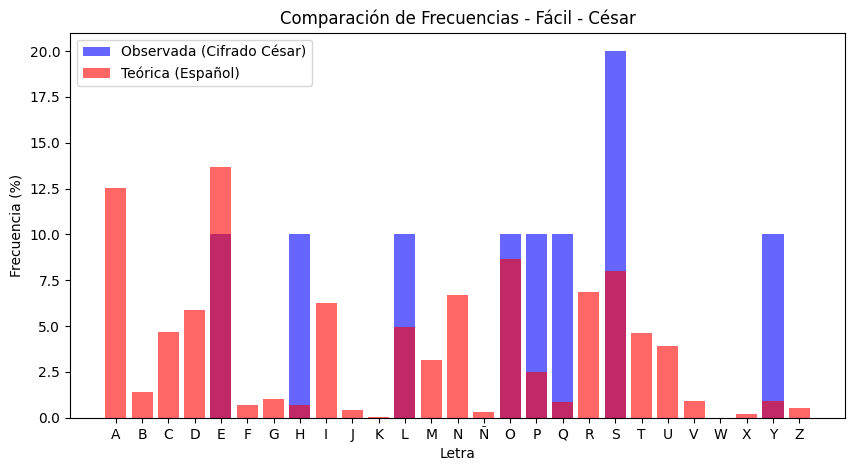

+-------+-------------+---------------+----------------+
| Letra | Teórica (%) | Observada (%) | Diferencia (%) |
+-------+-------------+---------------+----------------+
|   A   |    12.53    |      0.0      |     12.53      |
|   B   |     1.42    |      0.0      |      1.42      |
|   C   |     4.68    |      0.0      |      4.68      |
|   D   |     5.86    |      0.0      |      5.86      |
|   E   |    13.68    |      10.0     |      3.68      |
|   F   |     0.69    |      0.0      |      0.69      |
|   G   |     1.01    |      0.0      |      1.01      |
|   H   |     0.7     |      10.0     |      9.3       |
|   I   |     6.25    |      0.0      |      6.25      |
|   J   |     0.44    |      0.0      |      0.44      |
|   K   |     0.02    |      0.0      |      0.02      |
|   L   |     4.97    |      10.0     |      5.03      |
|   M   |     3.15    |      0.0      |      3.15      |
|   N   |     6.71    |      0.0      |      6.71      |
|   Ñ   |     0.31    |      0.

In [35]:
import matplotlib.pyplot as plt
from prettytable import PrettyTable

# 📌 Distribución teórica del castellano
distribucion_teorica = {
    "A": 12.53, "B": 1.42, "C": 4.68, "D": 5.86, "E": 13.68, "F": 0.69, "G": 1.01, "H": 0.70,
    "I": 6.25, "J": 0.44, "K": 0.02, "L": 4.97, "M": 3.15, "N": 6.71, "Ñ": 0.31, "O": 8.68,
    "P": 2.51, "Q": 0.88, "R": 6.87, "S": 7.98, "T": 4.63, "U": 3.93, "V": 0.90, "W": 0.01,
    "X": 0.22, "Y": 0.90, "Z": 0.52
}

# 📌 Obtener la distribución observada del cifrado
def analizar_frecuencia(texto):
    total = len(texto)
    frecuencia = {letra: 0 for letra in distribucion_teorica.keys()}

    for letra in texto.upper():
        if letra in frecuencia:
            frecuencia[letra] += 1

    # Convertir a porcentaje
    for letra in frecuencia:
        frecuencia[letra] = (frecuencia[letra] / total) * 100 if total > 0 else 0
    
    return frecuencia

# 📌 Nivel Fácil
nivel = "Fácil"
valores = textos_facil[nivel]

# 🔐 Cifrado César
caesar_encrypted = caesar_cipher.encrypt(valores["texto"], valores["shift"])
caesar_frecuencia = analizar_frecuencia(caesar_encrypted)

# 📊 Graficar comparación de frecuencias
letras = list(distribucion_teorica.keys())
observada = [caesar_frecuencia[letra] for letra in letras]
teorica = [distribucion_teorica[letra] for letra in letras]

plt.figure(figsize=(10, 5))
plt.bar(letras, observada, alpha=0.6, label="Observada (Cifrado César)", color="blue")
plt.bar(letras, teorica, alpha=0.6, label="Teórica (Español)", color="red")
plt.xlabel("Letra")
plt.ylabel("Frecuencia (%)")
plt.title(f"Comparación de Frecuencias - {nivel} - César")
plt.legend()
plt.show()

# 📋 Tabla de diferencias
tabla = PrettyTable(["Letra", "Teórica (%)", "Observada (%)", "Diferencia (%)"])
for letra in letras:
    diferencia = round(abs(distribucion_teorica[letra] - caesar_frecuencia[letra]), 2)
    tabla.add_row([letra, distribucion_teorica[letra], caesar_frecuencia[letra], diferencia])

print(tabla)

### Nivel intermedio

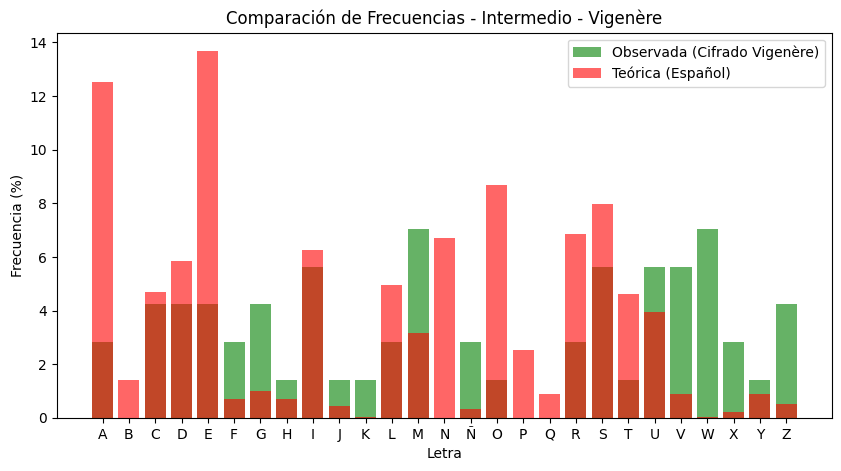

+-------+-------------+--------------------+----------------+
| Letra | Teórica (%) |   Observada (%)    | Diferencia (%) |
+-------+-------------+--------------------+----------------+
|   A   |    12.53    | 2.8169014084507045 |      9.71      |
|   B   |     1.42    |        0.0         |      1.42      |
|   C   |     4.68    | 4.225352112676056  |      0.45      |
|   D   |     5.86    | 4.225352112676056  |      1.63      |
|   E   |    13.68    | 4.225352112676056  |      9.45      |
|   F   |     0.69    | 2.8169014084507045 |      2.13      |
|   G   |     1.01    | 4.225352112676056  |      3.22      |
|   H   |     0.7     | 1.4084507042253522 |      0.71      |
|   I   |     6.25    | 5.633802816901409  |      0.62      |
|   J   |     0.44    | 1.4084507042253522 |      0.97      |
|   K   |     0.02    | 1.4084507042253522 |      1.39      |
|   L   |     4.97    | 2.8169014084507045 |      2.15      |
|   M   |     3.15    | 7.042253521126761  |      3.89      |
|   N   

In [36]:
# 📌 Nivel Intermedio
nivel = "Intermedio"
valores = textos_intermedio[nivel]

# 🔐 Cifrado Vigenère
vigenere_encrypted = vigenere_cipher.encrypt(valores["texto"], valores["key"])
vigenere_frecuencia = analizar_frecuencia(vigenere_encrypted)

# 📊 Graficar comparación de frecuencias
observada = [vigenere_frecuencia[letra] for letra in letras]

plt.figure(figsize=(10, 5))
plt.bar(letras, observada, alpha=0.6, label="Observada (Cifrado Vigenère)", color="green")
plt.bar(letras, teorica, alpha=0.6, label="Teórica (Español)", color="red")
plt.xlabel("Letra")
plt.ylabel("Frecuencia (%)")
plt.title(f"Comparación de Frecuencias - {nivel} - Vigenère")
plt.legend()
plt.show()

# 📋 Tabla de diferencias
tabla = PrettyTable(["Letra", "Teórica (%)", "Observada (%)", "Diferencia (%)"])
for letra in letras:
    diferencia = round(abs(distribucion_teorica[letra] - vigenere_frecuencia[letra]), 2)
    tabla.add_row([letra, distribucion_teorica[letra], vigenere_frecuencia[letra], diferencia])

print(tabla)

### Nivel difícil

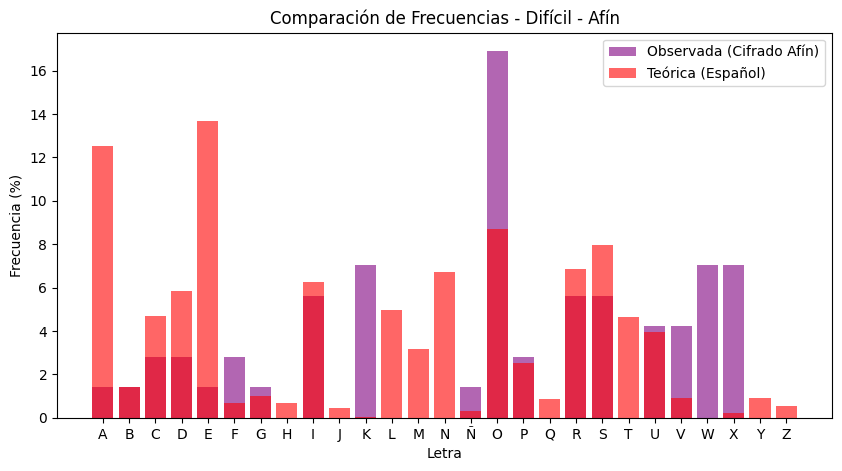

+-------+-------------+--------------------+----------------+
| Letra | Teórica (%) |   Observada (%)    | Diferencia (%) |
+-------+-------------+--------------------+----------------+
|   A   |    12.53    | 1.4084507042253522 |     11.12      |
|   B   |     1.42    | 1.4084507042253522 |      0.01      |
|   C   |     4.68    | 2.8169014084507045 |      1.86      |
|   D   |     5.86    | 2.8169014084507045 |      3.04      |
|   E   |    13.68    | 1.4084507042253522 |     12.27      |
|   F   |     0.69    | 2.8169014084507045 |      2.13      |
|   G   |     1.01    | 1.4084507042253522 |      0.4       |
|   H   |     0.7     |        0.0         |      0.7       |
|   I   |     6.25    | 5.633802816901409  |      0.62      |
|   J   |     0.44    |        0.0         |      0.44      |
|   K   |     0.02    | 7.042253521126761  |      7.02      |
|   L   |     4.97    |        0.0         |      4.97      |
|   M   |     3.15    |        0.0         |      3.15      |
|   N   

In [37]:
# 📌 Nivel Difícil
nivel = "Difícil"
valores = textos_dificil[nivel]

# 🔐 Cifrado Afín
affine_encrypted = affine_cipher.encrypt(valores["texto"], valores["alpha"], valores["beta"])
affine_frecuencia = analizar_frecuencia(affine_encrypted)

# 📊 Graficar comparación de frecuencias
observada = [affine_frecuencia[letra] for letra in letras]

plt.figure(figsize=(10, 5))
plt.bar(letras, observada, alpha=0.6, label="Observada (Cifrado Afín)", color="purple")
plt.bar(letras, teorica, alpha=0.6, label="Teórica (Español)", color="red")
plt.xlabel("Letra")
plt.ylabel("Frecuencia (%)")
plt.title(f"Comparación de Frecuencias - {nivel} - Afín")
plt.legend()
plt.show()

# 📋 Tabla de diferencias
tabla = PrettyTable(["Letra", "Teórica (%)", "Observada (%)", "Diferencia (%)"])
for letra in letras:
    diferencia = round(abs(distribucion_teorica[letra] - affine_frecuencia[letra]), 2)
    tabla.add_row([letra, distribucion_teorica[letra], affine_frecuencia[letra], diferencia])

print(tabla)